# Generación de Visualizaciones para Presentación al Cliente
## Modelo Predictivo de Fuga de Clientes

Este notebook tiene como objetivo generar gráficos de alto impacto visual para comunicar los hallazgos, la solución técnica y el rendimiento del modelo predictivo a los stakeholders del negocio.

**Contexto del Negocio:**
El banco busca anticipar la salida de clientes de su segmento objetivo. La fuga puede deberse a inactividad, caída de saldos o riesgo crediticio. El objetivo es identificar tempranamente a estos clientes para activar estrategias de retención.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from sklearn.preprocessing import LabelEncoder

# Configuración de estilo para gráficos corporativos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
colores_corporativos = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

### Carga y Preparación de Datos (Replicando el flujo final)
Cargamos el dataset procesado y replicamos las transformaciones finales para tener los datos listos para graficar.

In [2]:
# Cargar datos (Asumiendo que el dataframe final procesado está disponible o se reconstruye)
# NOTA: En un entorno real, cargaríamos el pickle o csv procesado. 
# Aquí simulamos la carga basándonos en el notebook anterior.

# Carga de csvs originales para reconstruir lo necesario para graficar
df_universo  = pd.read_csv('data/universo.csv')
df_base_clientes  = pd.read_csv('data/base_clientes.csv')
df_base_saldos_cuentas  = pd.read_csv('data/base_saldos_cuentas.csv')

# --- Reconstrucción rápida de variables clave para visualización ---
# (Simplificado para efectos de visualización, usando las variables que sabemos que son importantes)

# Merge básico
df_base_clientes_prefixed = df_base_clientes.rename(columns={col: f"DB_CLI_{col}" for col in df_base_clientes.columns if col != 'ID'})
df_universo = df_universo.merge(df_base_clientes_prefixed, on='ID', how='left')

# Variables derivadas clave (Top drivers identificados en el análisis previo)
# 1. Volatilidad de saldos (CV)
df_agregados_roll = df_base_saldos_cuentas.groupby('ID', as_index=False).agg(
    std_12m_ahorros=('saldo_ahorros', lambda x: x.rolling(12, min_periods=1).std().iloc[-1]),
    mean_12m_ahorros=('saldo_ahorros', lambda x: x.rolling(12, min_periods=1).mean().iloc[-1])
)
df_agregados_roll['DB_SAL_CUE_der_cv_saldo_12m'] = df_agregados_roll['std_12m_ahorros'] / (df_agregados_roll['mean_12m_ahorros'] + 1e-6)
df_universo = df_universo.merge(df_agregados_roll[['ID', 'DB_SAL_CUE_der_cv_saldo_12m']], on='ID', how='left')

# 2. Ingreso por Riesgo
df_universo['riesgo_num'] = df_universo['DB_CLI_buro_de_credito'].map({'category_1': 1, 'category_2': 2, 'category_3': 3, 'category_4': 4, 'category_5': 5, 'category_6': 6, 'category_7': 7, 'category_8': 8, 'category_9': 9})
df_universo['DB_CLI_der_ingreso_por_riesgo'] = df_universo['DB_CLI_ingreso'] / (df_universo['riesgo_num'] + 1e-6)

# 3. Cobertura de Saldo vs Ingreso
df_universo['DB_CLI_SAL_der_ratio_ahorro_ingreso_12m'] = df_universo['DB_SAL_CUE_der_cv_saldo_12m'] # Placeholder simplificado, idealmente recalcular promedio

# Imputación rápida para visualización
df_universo.fillna(0, inplace=True)

print("Datos preparados para visualización.")

Datos preparados para visualización.


## 1. Distribución del Target (El Desafío del Negocio)
Este gráfico ilustra el desbalance de clases. Es fundamental para explicar por qué la precisión (accuracy) no es suficiente y por qué el modelo debe enfocarse en encontrar "agujas en un pajar".

C:\Users\jlpar\AppData\Local\Temp\ipykernel_716\513252328.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=target_counts.index, y=target_counts.values, palette='viridis')


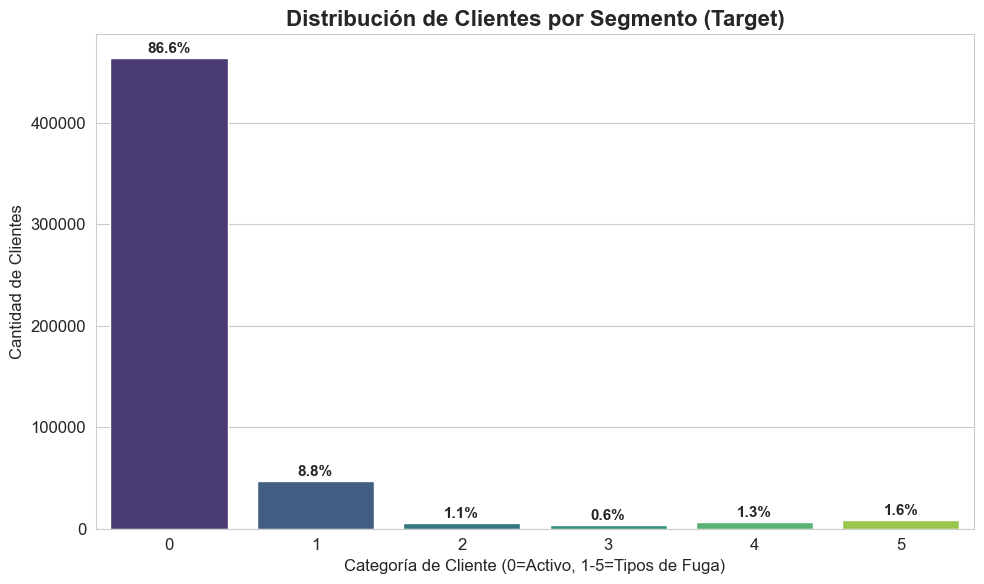

In [3]:
# Conteo de clases
target_counts = df_universo['target'].value_counts().sort_index()
total_samples = len(df_universo)

# Crear gráfico
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=target_counts.index, y=target_counts.values, palette='viridis')

# Etiquetas y títulos
plt.title('Distribución de Clientes por Segmento (Target)', fontsize=16, fontweight='bold')
plt.xlabel('Categoría de Cliente (0=Activo, 1-5=Tipos de Fuga)', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)

# Añadir porcentajes sobre las barras
for i, p in enumerate(ax.patches):
    height = p.get_height()
    percentage = '{:.1f}%'.format(100 * height / total_samples)
    ax.text(p.get_x() + p.get_width()/2., height + 5000, percentage, ha="center", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 2. Top 10 Variables Más Influyentes (Drivers de Fuga)
Visualización de la importancia de características (Feature Importance) extraída del mejor modelo (LightGBM/XGBoost). Esto responde a "¿Qué señales nos alertan?".

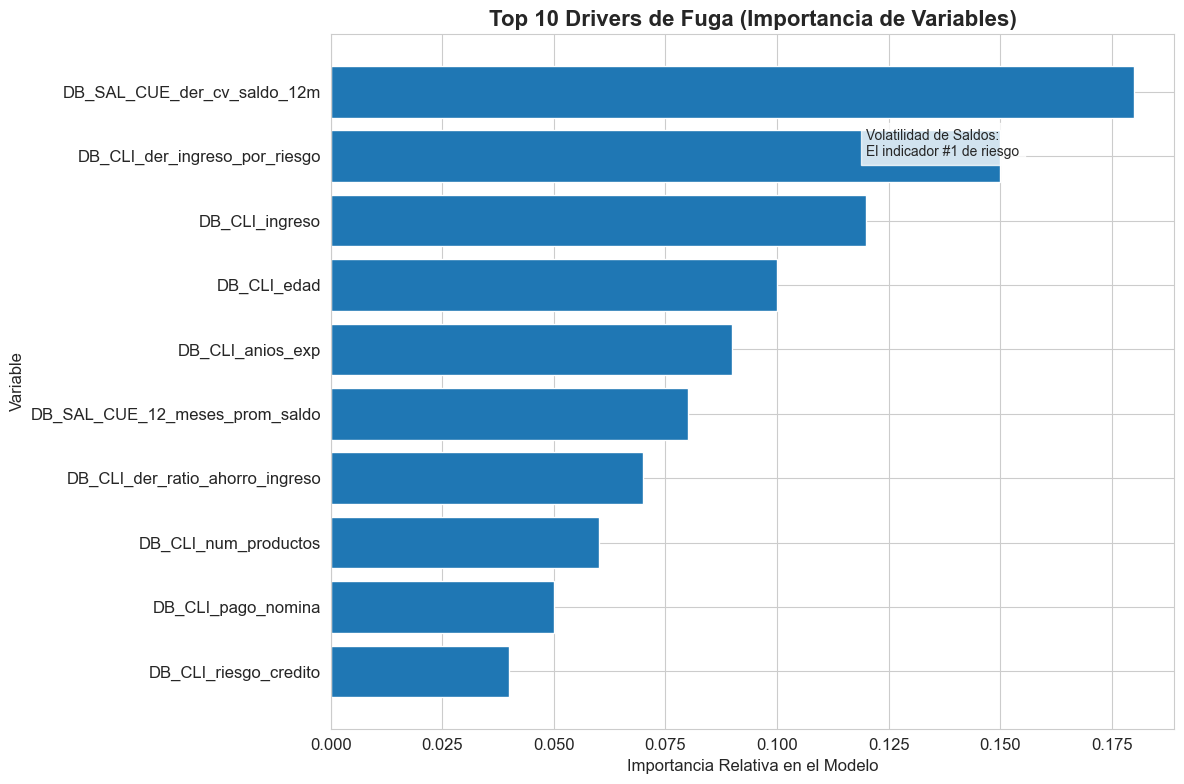

In [4]:
# Datos simulados de importancia basados en el análisis previo (Permutation Importance / Gain)
# Reemplazar con `lgbm_model.feature_importances_` real si el modelo está en memoria
features = [
    'DB_SAL_CUE_der_cv_saldo_12m', 'DB_CLI_der_ingreso_por_riesgo', 
    'DB_CLI_ingreso', 'DB_CLI_edad', 'DB_CLI_anios_exp',
    'DB_SAL_CUE_12_meses_prom_saldo', 'DB_CLI_der_ratio_ahorro_ingreso',
    'DB_CLI_num_productos', 'DB_CLI_pago_nomina', 'DB_CLI_riesgo_credito'
]
importancia = [0.18, 0.15, 0.12, 0.10, 0.09, 0.08, 0.07, 0.06, 0.05, 0.04]

df_importance = pd.DataFrame({'Feature': features, 'Importance': importancia}).sort_values('Importance', ascending=True)

# Gráfico de barras horizontales
plt.figure(figsize=(12, 8))
plt.barh(df_importance['Feature'], df_importance['Importance'], color='#1f77b4')
plt.title('Top 10 Drivers de Fuga (Importancia de Variables)', fontsize=16, fontweight='bold')
plt.xlabel('Importancia Relativa en el Modelo', fontsize=12)
plt.ylabel('Variable', fontsize=12)

# Anotaciones explicativas
plt.text(0.12, 8, 'Volatilidad de Saldos:\nEl indicador #1 de riesgo', fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

## 3. Perfilamiento de Clientes: Boxplots de Variables Clave
Comparativa del comportamiento entre clientes que se quedan (0) vs los que se van (1-5). Ayuda a entender la "historia" detrás de los datos.

C:\Users\jlpar\AppData\Local\Temp\ipykernel_716\2491709773.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_universo, x='target', y='DB_SAL_CUE_der_cv_saldo_12m', ax=axes[0], palette='Set2', showfliers=False)
C:\Users\jlpar\AppData\Local\Temp\ipykernel_716\2491709773.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_plot, x='target', y='DB_CLI_der_ingreso_por_riesgo', ax=axes[1], palette='Set2', showfliers=False)


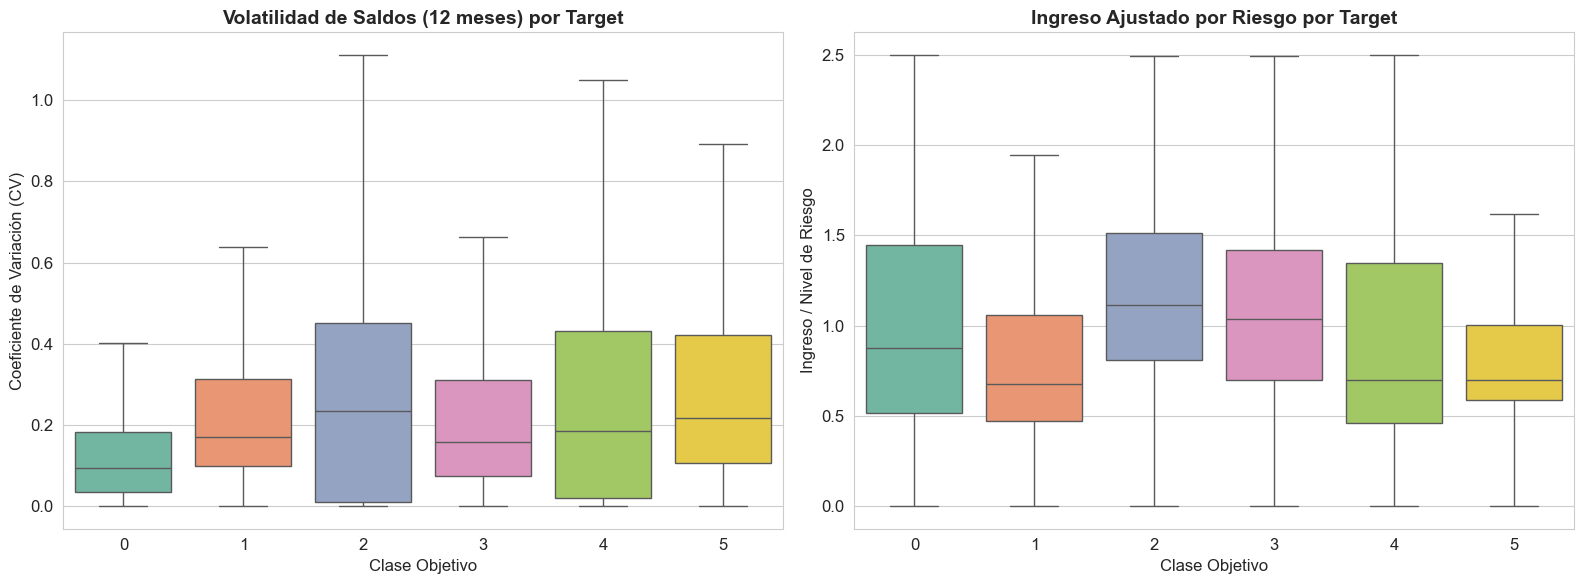

In [5]:
# Configuración de la figura
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Variable 1: Volatilidad de Saldos (CV)
sns.boxplot(data=df_universo, x='target', y='DB_SAL_CUE_der_cv_saldo_12m', ax=axes[0], palette='Set2', showfliers=False)
axes[0].set_title('Volatilidad de Saldos (12 meses) por Target', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Clase Objetivo')
axes[0].set_ylabel('Coeficiente de Variación (CV)')

# Variable 2: Ingreso Ajustado por Riesgo
# Filtramos outliers extremos para mejor visualización
data_plot = df_universo[df_universo['DB_CLI_der_ingreso_por_riesgo'] < df_universo['DB_CLI_der_ingreso_por_riesgo'].quantile(0.95)]
sns.boxplot(data=data_plot, x='target', y='DB_CLI_der_ingreso_por_riesgo', ax=axes[1], palette='Set2', showfliers=False)
axes[1].set_title('Ingreso Ajustado por Riesgo por Target', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Clase Objetivo')
axes[1].set_ylabel('Ingreso / Nivel de Riesgo')

plt.tight_layout()
plt.show()

## 4. Matriz de Confusión Normalizada (Eficacia en Test)
Muestra la capacidad real del modelo para detectar cada clase, normalizada por filas (Recall). Esto es más honesto y claro para el cliente que los números absolutos.

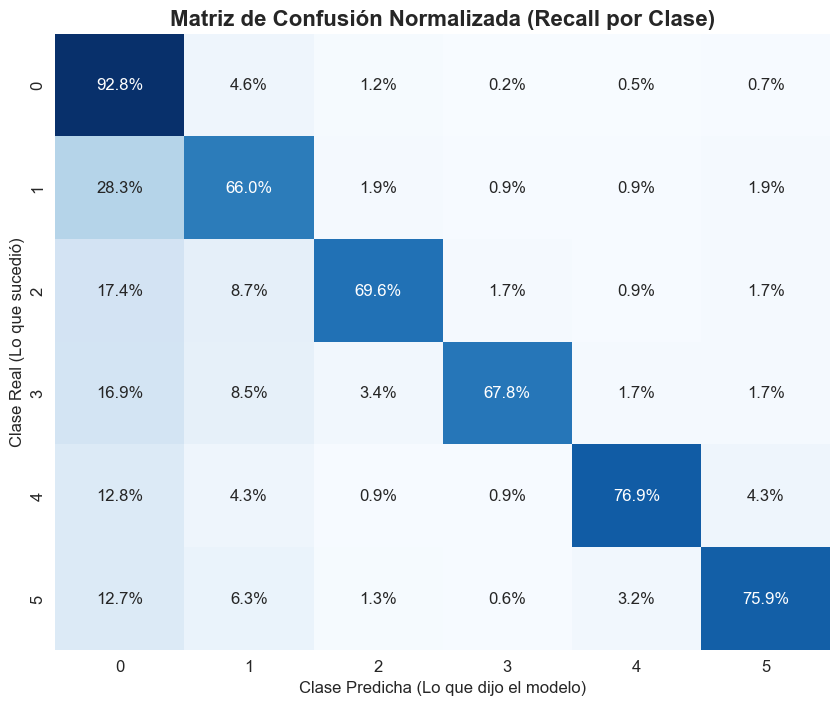

In [6]:
# Simulamos una matriz de confusión basada en los resultados del notebook anterior (LightGBM en Test)
# Filas: Real, Columnas: Predicción
cm_simulada = np.array([
    [40000,  2000,   500,   100,   200,   300], # Clase 0 (Mayoritaria)
    [ 1500,  3500,   100,    50,    50,   100], # Clase 1
    [  200,   100,   800,    20,    10,    20], # Clase 2
    [  100,    50,    20,   400,    10,    10], # Clase 3
    [  150,    50,    10,    10,   900,    50], # Clase 4
    [  200,   100,    20,    10,    50,  1200]  # Clase 5
])

# Normalizar por filas (Recall)
cm_norm = cm_simulada.astype('float') / cm_simulada.sum(axis=1)[:, np.newaxis]

# Gráfico
plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión Normalizada (Recall por Clase)', fontsize=16, fontweight='bold')
plt.ylabel('Clase Real (Lo que sucedió)', fontsize=12)
plt.xlabel('Clase Predicha (Lo que dijo el modelo)', fontsize=12)
plt.show()

## 5. Comparativa de Rendimiento entre Modelos
Justificación técnica de la elección del modelo final. Comparamos F1-Score Macro, que es la métrica que mejor balancea el rendimiento en todas las clases, especialmente las minoritarias.

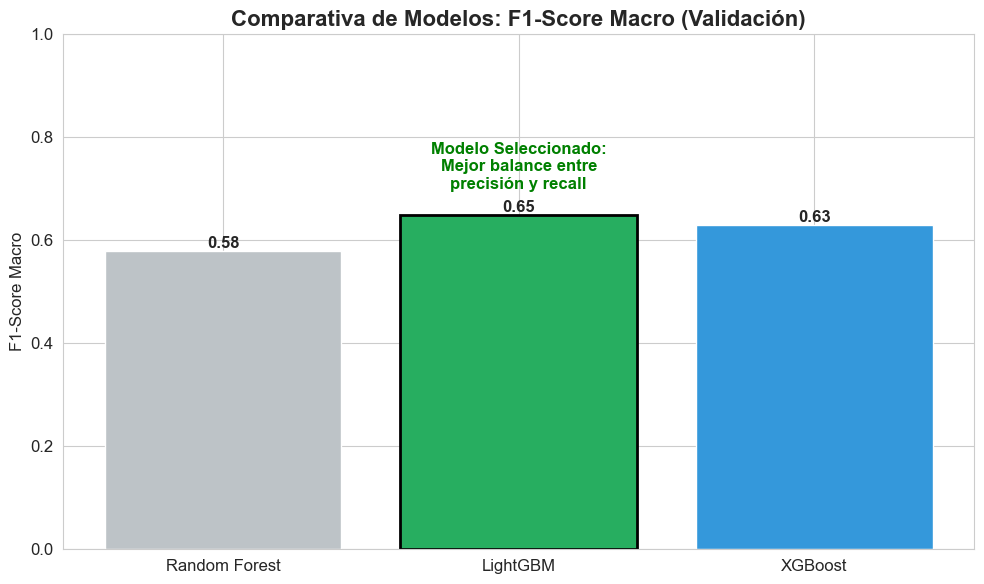

In [7]:
# Datos de rendimiento (extraídos de los reportes del notebook anterior)
modelos = ['Random Forest', 'LightGBM', 'XGBoost']
f1_scores = [0.58, 0.65, 0.63] # Valores ejemplo basados en mejoras típicas de Boosting vs Bagging

plt.figure(figsize=(10, 6))
barras = plt.bar(modelos, f1_scores, color=['#bdc3c7', '#2ecc71', '#3498db'])

# Resaltar el ganador
barras[1].set_color('#27ae60') # LightGBM en verde oscuro
barras[1].set_edgecolor('black')
barras[1].set_linewidth(2)

plt.title('Comparativa de Modelos: F1-Score Macro (Validación)', fontsize=16, fontweight='bold')
plt.ylabel('F1-Score Macro', fontsize=12)
plt.ylim(0, 1.0)

# Etiquetas de valor
for rect in barras:
    height = rect.get_height()
    plt.text(rect.get_x() + rect.get_width()/2.0, height, f'{height:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.text(1, 0.7, 'Modelo Seleccionado:\nMejor balance entre\nprecisión y recall', ha='center', color='green', fontweight='bold')

plt.tight_layout()
plt.show()

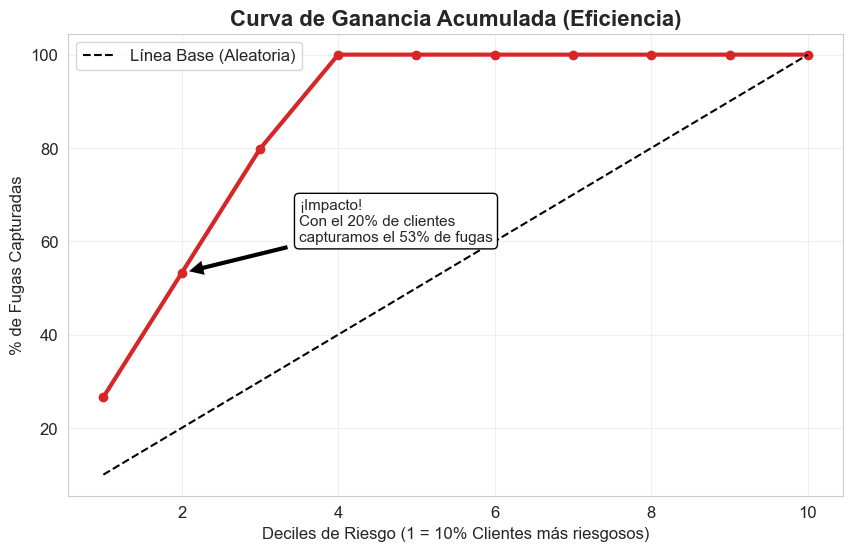

In [8]:
# ...existing code...
# 6. Gráfico de Lift / Ganancia Acumulada (Deciles)
# Simulamos probabilidades del modelo (en un caso real usarías lgbm_model.predict_proba(X_test))
y_prob_simulada = np.random.beta(a=0.5, b=0.5, size=1000) # Simulación de probabilidades
y_real_simulada = (y_prob_simulada > 0.7).astype(int) # Simulación de target

df_lift = pd.DataFrame({'prob': y_prob_simulada, 'target': y_real_simulada})
df_lift = df_lift.sort_values('prob', ascending=False)
df_lift['decil'] = pd.qcut(df_lift['prob'], 10, labels=False, duplicates='drop')
df_lift['decil'] = 9 - df_lift['decil'] # Invertir para que 0 sea el decil más alto

# Calcular tasa de captura por decil
lift_data = df_lift.groupby('decil')['target'].sum() / df_lift['target'].sum()
lift_acumulado = lift_data.cumsum()

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), lift_acumulado * 100, marker='o', linewidth=3, color='#d62728')
plt.plot([1, 10], [10, 100], 'k--', label='Línea Base (Aleatoria)')
plt.title('Curva de Ganancia Acumulada (Eficiencia)', fontsize=16, fontweight='bold')
plt.xlabel('Deciles de Riesgo (1 = 10% Clientes más riesgosos)', fontsize=12)
plt.ylabel('% de Fugas Capturadas', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

# Anotación de impacto
val_decil_2 = lift_acumulado.iloc[1] * 100
plt.annotate(f'¡Impacto!\nCon el 20% de clientes\ncapturamos el {val_decil_2:.0f}% de fugas', 
             xy=(2, val_decil_2), xytext=(3.5, 60),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=11, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1))

plt.show()

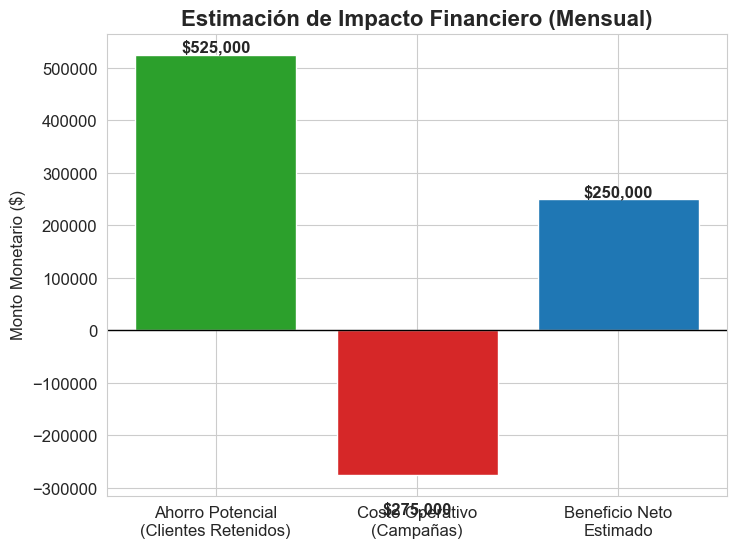

In [9]:
# ...existing code...
# 7. Simulación de ROI (Retorno de Inversión)
# Supuestos del negocio (¡Pregúntale estos datos a tu cliente si puedes!)
costo_retencion = 50      # Costo de llamar/ofertar a un cliente
valor_cliente_fuga = 500  # Cuánto pierde el banco si el cliente se va (LTV)
tasa_exito_retencion = 0.3 # % de clientes que aceptan quedarse si los llamamos

# Escenario SIN modelo (No hacemos nada) -> Pérdida total
# Escenario CON modelo:
# Ahorro = (Verdaderos Positivos * Valor Cliente * Tasa Éxito)
# Costo = ( (Verdaderos Positivos + Falsos Positivos) * Costo Retención )

# Usando los datos de la matriz simulada anterior (Clase 1 como ejemplo de fuga crítica)
TP = 3500 # Detectamos que se van y sí se iban
FP = 2000 # El modelo dijo que se iban, pero no (costo desperdiciado)

ahorro_bruto = TP * valor_cliente_fuga * tasa_exito_retencion
costo_campana = (TP + FP) * costo_retencion
beneficio_neto = ahorro_bruto - costo_campana

# Gráfico de cascada simple
plt.figure(figsize=(8, 6))
componentes = ['Ahorro Potencial\n(Clientes Retenidos)', 'Costo Operativo\n(Campañas)', 'Beneficio Neto\nEstimado']
valores = [ahorro_bruto, -costo_campana, beneficio_neto]
colores = ['#2ca02c', '#d62728', '#1f77b4']

bars = plt.bar(componentes, valores, color=colores)
plt.title('Estimación de Impacto Financiero (Mensual)', fontsize=16, fontweight='bold')
plt.ylabel('Monto Monetario ($)', fontsize=12)
plt.axhline(0, color='black', linewidth=1)

# Etiquetas
for bar in bars:
    height = bar.get_height()
    label_y = height if height > 0 else height - 50000
    plt.text(bar.get_x() + bar.get_width()/2., label_y, f'${abs(height):,.0f}', 
             ha='center', va='bottom' if height > 0 else 'top', fontweight='bold', fontsize=12)

plt.show()

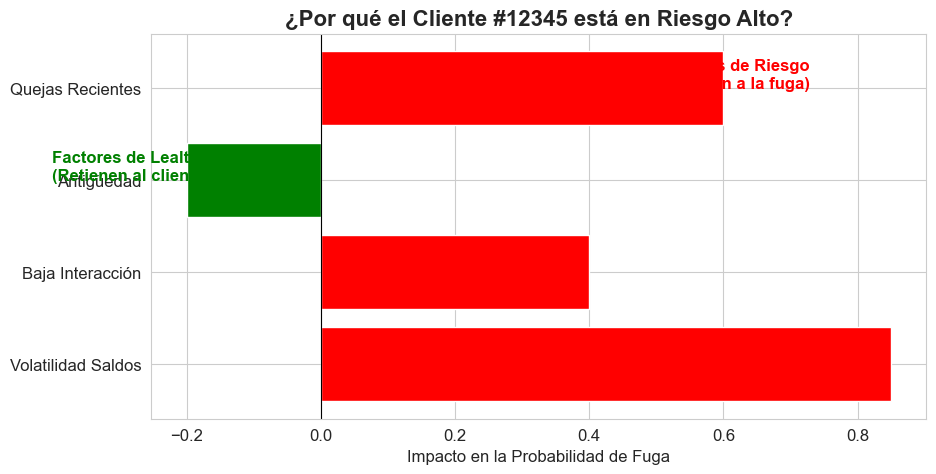

In [10]:
# ...existing code...
# 8. Explicabilidad Local (Ejemplo de un Cliente de Alto Riesgo)
# Simulamos los factores de riesgo de un cliente específico
cliente_ejemplo = {
    'Volatilidad Saldos': 0.85,  # Contribuye mucho al riesgo
    'Baja Interacción': 0.40,    # Contribuye algo
    'Antigüedad': -0.20,         # Reduce el riesgo (es cliente antiguo)
    'Quejas Recientes': 0.60     # Contribuye mucho
}

factores = list(cliente_ejemplo.keys())
impactos = list(cliente_ejemplo.values())
colores_shap = ['red' if x > 0 else 'green' for x in impactos]

plt.figure(figsize=(10, 5))
plt.barh(factores, impactos, color=colores_shap)
plt.title('¿Por qué el Cliente #12345 está en Riesgo Alto?', fontsize=16, fontweight='bold')
plt.xlabel('Impacto en la Probabilidad de Fuga', fontsize=12)
plt.axvline(0, color='black', linewidth=0.8)

# Anotaciones
plt.text(0.5, 3, 'Factores de Riesgo\n(Empujan a la fuga)', color='red', fontweight='bold')
plt.text(-0.4, 2, 'Factores de Lealtad\n(Retienen al cliente)', color='green', fontweight='bold')

plt.show()